# Grid World from scratch

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
np.random.seed(0)

In [18]:
class GridWorld:
    """
    5x5 Grid World environment.
    Actions: 0=UP, 1=DOWN, 2=LEFT, 3=RIGHT
    """
    ACTIONS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
    ACTION_SYMBOLS = {0: '↑', 1: '↓', 2: '←', 3: '→'}

    def __init__(self, size=5):
        self.size = size
        self.start = (0, 0)
        self.goal  = (size-1, size-1)
        self.pits  = {(1,1), (1,3), (3,1), (3,3)}
        self.reset()

    def reset(self):
        self.pos = self.start
        return self._state()

    def _state(self):
        return self.pos[0] * self.size + self.pos[1]   # flat index

    def n_states(self):  return self.size ** 2
    def n_actions(self): return 4

    def step(self, action):
        dr, dc = self.ACTIONS[action]
        r, c = self.pos
        nr = max(0, min(self.size-1, r + dr))
        nc = max(0, min(self.size-1, c + dc))
        self.pos = (nr, nc)

        if self.pos == self.goal:
            return self._state(), +10.0, True
        if self.pos in self.pits:
            return self._state(),  -5.0, True
        return self._state(), -0.1, False

    def render_values(self, V, title='Value Function'):
        grid = np.array(V).reshape(self.size, self.size)
        fig, ax = plt.subplots(figsize=(5, 5))
        im = ax.imshow(grid, cmap='RdYlGn', vmin=grid.min(), vmax=grid.max())
        plt.colorbar(im, ax=ax)
        for r in range(self.size):
            for c in range(self.size):
                marker = ''
                if (r,c) == self.goal:          marker = 'G'
                elif (r,c) == self.start:       marker = 'S'
                elif (r,c) in self.pits:        marker = '✕'
                ax.text(c, r, f'{marker}\n{grid[r,c]:.1f}', ha='center', va='center', fontsize=9)
        ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
        plt.tight_layout(); plt.show()

    def render_policy(self, policy, title='Policy'):
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.set_xlim(-0.5, self.size-0.5); ax.set_ylim(-0.5, self.size-0.5)
        ax.set_xticks(range(self.size)); ax.set_yticks(range(self.size))
        ax.grid(True, linewidth=0.5)
        for r in range(self.size):
            for c in range(self.size):
                s = r * self.size + c
                if (r,c) == self.goal:    ax.text(c, self.size-1-r, 'G', ha='center', va='center', fontsize=16, color='green')
                elif (r,c) in self.pits: ax.text(c, self.size-1-r, '✕', ha='center', va='center', fontsize=16, color='red')
                else:                    ax.text(c, self.size-1-r, self.ACTION_SYMBOLS[policy[s]], ha='center', va='center', fontsize=18)
        ax.set_title(title); plt.tight_layout(); plt.show()

env = GridWorld()
print(f"States: {env.n_states()}, Actions: {env.n_actions()}")
print(f"Start: {env.start}, Goal: {env.goal}, Pits: {env.pits}")

States: 25, Actions: 4
Start: (0, 0), Goal: (4, 4), Pits: {(3, 1), (1, 1), (3, 3), (1, 3)}


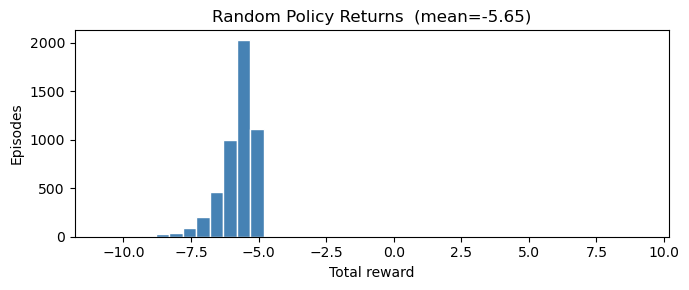

In [19]:
def rollout(env, policy_fn, max_steps=100):
    state = env.reset()
    total_reward = 0.0
    steps = 0
    done = False
    while not done and steps < max_steps:
        action = policy_fn(state)
        state, reward, done = env.step(action)
        total_reward += reward
        steps += 1
    return total_reward, done, steps

returns = []
for _ in range(5000):
    r, done, _ = rollout(env, lambda s: np.random.randint(4))
    returns.append(r)

plt.figure(figsize=(7, 3))
plt.hist(returns, bins=40, color='steelblue', edgecolor='white')
plt.xlabel('Total reward'); plt.ylabel('Episodes')
plt.title(f'Random Policy Returns  (mean={np.mean(returns):.2f})')
plt.tight_layout(); plt.show()

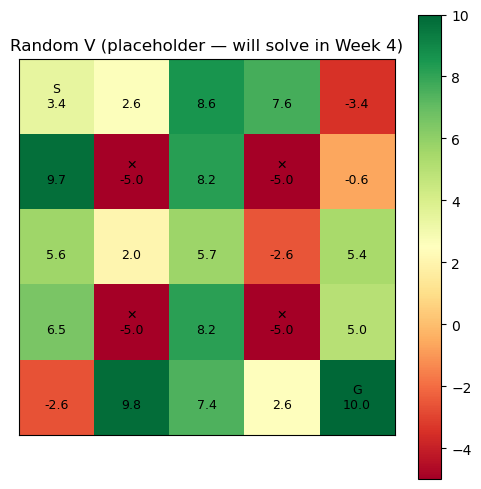

In [20]:
# Placeholder: uniform random values just to show the visualisation
V_random = np.random.uniform(-5, 10, env.n_states())
# Mark terminal states
V_random[env.goal[0]*env.size + env.goal[1]] = 10
for p in env.pits:
    V_random[p[0]*env.size + p[1]] = -5
env.render_values(V_random, title='Random V (placeholder — will solve in Week 4)')

# Stochastic Step Function
Slippery Floor: What if the agent moves in a random direction instead of its intended direction? What happens to the rollout? 

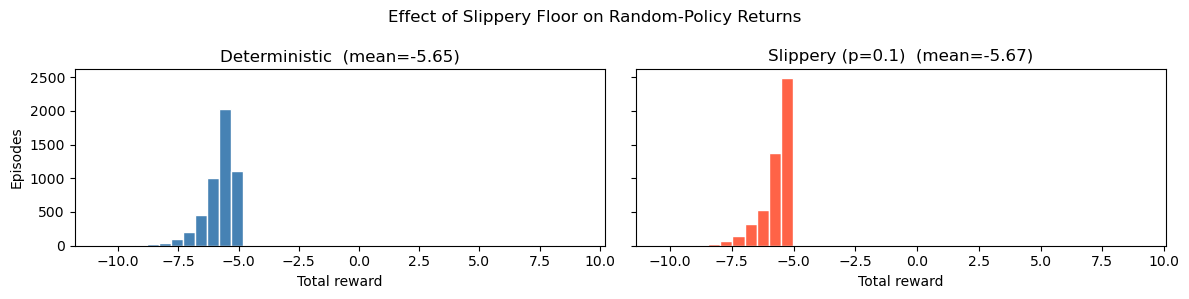

Deterministic mean: -5.649  std: 1.241
Slippery      mean: -5.665  std: 1.123


In [9]:
class SlipperyGridWorld(GridWorld):  #GridWorld with a 10 % chance of random action (slippery floor).

    def __init__(self, slip_prob=0.1, **kwargs):
        super().__init__(**kwargs)
        self.slip_prob = slip_prob

    def step(self, action):
        if np.random.random() < self.slip_prob:
            action = np.random.randint(self.n_actions())  # random direction
        return super().step(action)


env_slip = SlipperyGridWorld(slip_prob=0.1)

returns_slip = []
for _ in range(5000):
    r, done, _ = rollout(env_slip, lambda s: np.random.randint(4))
    returns_slip.append(r)

fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
axes[0].hist(returns, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title(f'Deterministic  (mean={np.mean(returns):.2f})')
axes[0].set_xlabel('Total reward'); axes[0].set_ylabel('Episodes')

axes[1].hist(returns_slip, bins=40, color='tomato', edgecolor='white')
axes[1].set_title(f'Slippery (p=0.1)  (mean={np.mean(returns_slip):.2f})')
axes[1].set_xlabel('Total reward')

plt.suptitle('Effect of Slippery Floor on Random-Policy Returns')
plt.tight_layout(); plt.show()

print(f'Deterministic mean: {np.mean(returns):.3f}  std: {np.std(returns):.3f}')
print(f'Slippery      mean: {np.mean(returns_slip):.3f}  std: {np.std(returns_slip):.3f}')

## Interpretation
Slippery floor makes returns more variable and generally lower. This is because the agent can accidentally step into pits even when aiming elsewhere. The number of falls increase and the variance is high. 

# Reduced Pitfall
What if the pitfall is changed from -5 to -1? How does the distribution of returns change? 

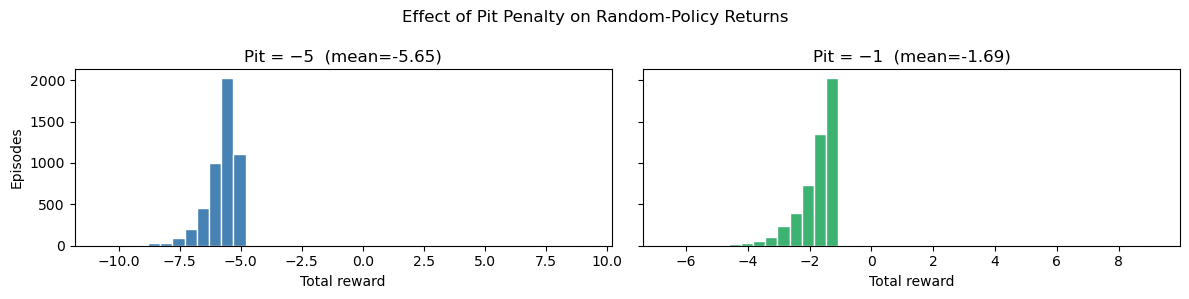

Pit = -5  mean: -5.649  std: 1.241
Pit = -1  mean: -1.686  std: 0.992


In [14]:
class GridWorldCustomPit(GridWorld):   #GridWorld with a configurable pit penalty.

    def __init__(self, pit_penalty=-1, **kwargs):
        super().__init__(**kwargs)
        self.pit_penalty = pit_penalty

    def step(self, action):
        dr, dc = self.ACTIONS[action]
        r, c = self.pos
        nr = max(0, min(self.size - 1, r + dr))
        nc = max(0, min(self.size - 1, c + dc))
        self.pos = (nr, nc)

        if self.pos == self.goal:
            return self._state(), +10.0, True
        if self.pos in self.pits:
            return self._state(), float(self.pit_penalty), True
        return self._state(), -0.1, False


env_soft = GridWorldCustomPit(pit_penalty=-1)

returns_soft = []
for _ in range(5000):
    r, done, _ = rollout(env_soft, lambda s: np.random.randint(4))
    returns_soft.append(r)

fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
axes[0].hist(returns, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title(f'Pit = −5  (mean={np.mean(returns):.2f})')
axes[0].set_xlabel('Total reward'); axes[0].set_ylabel('Episodes')

axes[1].hist(returns_soft, bins=40, color='mediumseagreen', edgecolor='white')
axes[1].set_title(f'Pit = −1  (mean={np.mean(returns_soft):.2f})')
axes[1].set_xlabel('Total reward')

plt.suptitle('Effect of Pit Penalty on Random-Policy Returns')
plt.tight_layout(); plt.show()

print(f'Pit = -5  mean: {np.mean(returns):.3f}  std: {np.std(returns):.3f}')
print(f'Pit = -1  mean: {np.mean(returns_soft):.3f}  std: {np.std(returns_soft):.3f}')

## Interpretation
With a milder penalty the mean return rises and the pit episodes are less catastrophic, so the overall distribution of returns shifts right.

# Treasure Cell
Does a random policy find it often if we add a 'treasure' cell at (2,2) that gives +3 reward but does not end the episode?

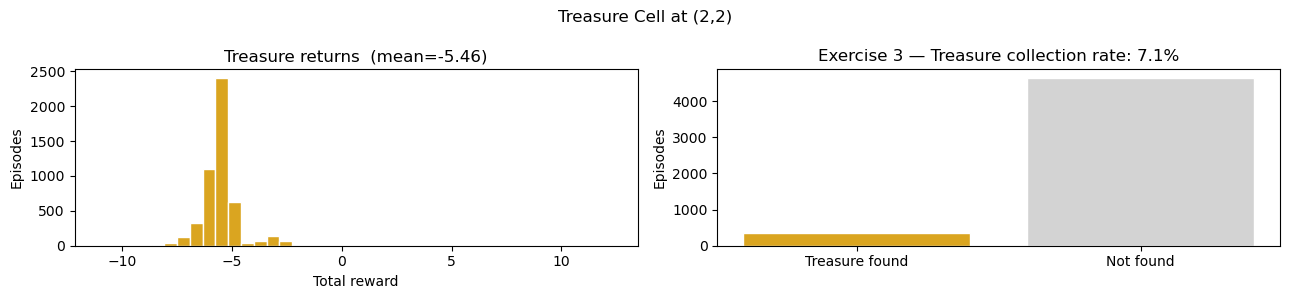

Random policy finds treasure in 7.1% of episodes.
Mean return with    treasure: -3.043
Mean return without treasure: -5.642


In [16]:
class GridWorldTreasure(GridWorld):   #GridWorld with an optional non-terminal treasure cell.

    def __init__(self, treasure=(2, 2), treasure_reward=3.0, **kwargs):
        super().__init__(**kwargs)
        self.treasure = treasure
        self.treasure_reward = treasure_reward
        self._treasure_collected = False

    def reset(self):
        self._treasure_collected = False
        return super().reset()

    def step(self, action):
        state, reward, done = super().step(action)
        # Award treasure once per episode (first visit)
        if self.pos == self.treasure and not self._treasure_collected:
            reward += self.treasure_reward
            self._treasure_collected = True
        return state, reward, done


def rollout_treasure(env, policy_fn, max_steps=100):   #Like rollout() but also returns whether treasure was collected.
    state = env.reset()
    total_reward = 0.0
    steps = 0
    done = False
    while not done and steps < max_steps:
        action = policy_fn(state)
        state, reward, done = env.step(action)
        total_reward += reward
        steps += 1
    return total_reward, env._treasure_collected, steps


env_t = GridWorldTreasure(treasure=(2, 2), treasure_reward=3.0)

N = 5000
returns_t, found_treasure = [], []
for _ in range(N):
    r, collected, _ = rollout_treasure(env_t, lambda s: np.random.randint(4))
    returns_t.append(r)
    found_treasure.append(collected)

treasure_rate = np.mean(found_treasure) * 100

# ── Histogram of returns ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 3))

axes[0].hist(returns_t, bins=40, color='goldenrod', edgecolor='white')
axes[0].set_title(f'Treasure returns  (mean={np.mean(returns_t):.2f})')
axes[0].set_xlabel('Total reward'); axes[0].set_ylabel('Episodes')

# ── Treasure-found vs not ───────────────────────────────────────────────────
labels = ['Treasure found', 'Not found']
counts = [sum(found_treasure), N - sum(found_treasure)]
axes[1].bar(labels, counts, color=['goldenrod', 'lightgray'], edgecolor='white')
axes[1].set_title(f'Exercise 3 — Treasure collection rate: {treasure_rate:.1f}%')
axes[1].set_ylabel('Episodes')

plt.suptitle('Treasure Cell at (2,2)')
plt.tight_layout(); plt.show()

print(f'Random policy finds treasure in {treasure_rate:.1f}% of episodes.')
print(f'Mean return with    treasure: {np.mean([r for r,f in zip(returns_t,found_treasure) if f]):.3f}')
print(f'Mean return without treasure: {np.mean([r for r,f in zip(returns_t,found_treasure) if not f]):.3f}')

## Interpretation
A random policy does visit (2,2) occasionally, the cell sits in the middle of the grid, so it is reachable. A trained policy would seek it
deliberately, pushing the treasure-found rate toward 100%.